### Stock Price Prediction using LSTM in TensorFlow.

##### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loading Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/23-Stock%20Price%20Prediction/all_stocks_5yr.csv

--2026-03-14 06:24:33--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/23-Stock%20Price%20Prediction/all_stocks_5yr.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29580549 (28M) [text/plain]
Saving to: ‘all_stocks_5yr.csv’

all_stocks_5yr.csv  100%[===================>]  28.21M  91.8MB/s    in 0.3s    

2026-03-14 06:24:34 (91.8 MB/s) - ‘all_stocks_5yr.csv’ saved [29580549/29580549]



In [3]:
df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


##### 3. Preprocessing

1. Exploratory Data Analysis

In [5]:
df.shape

(619040, 7)

In [4]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [7]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


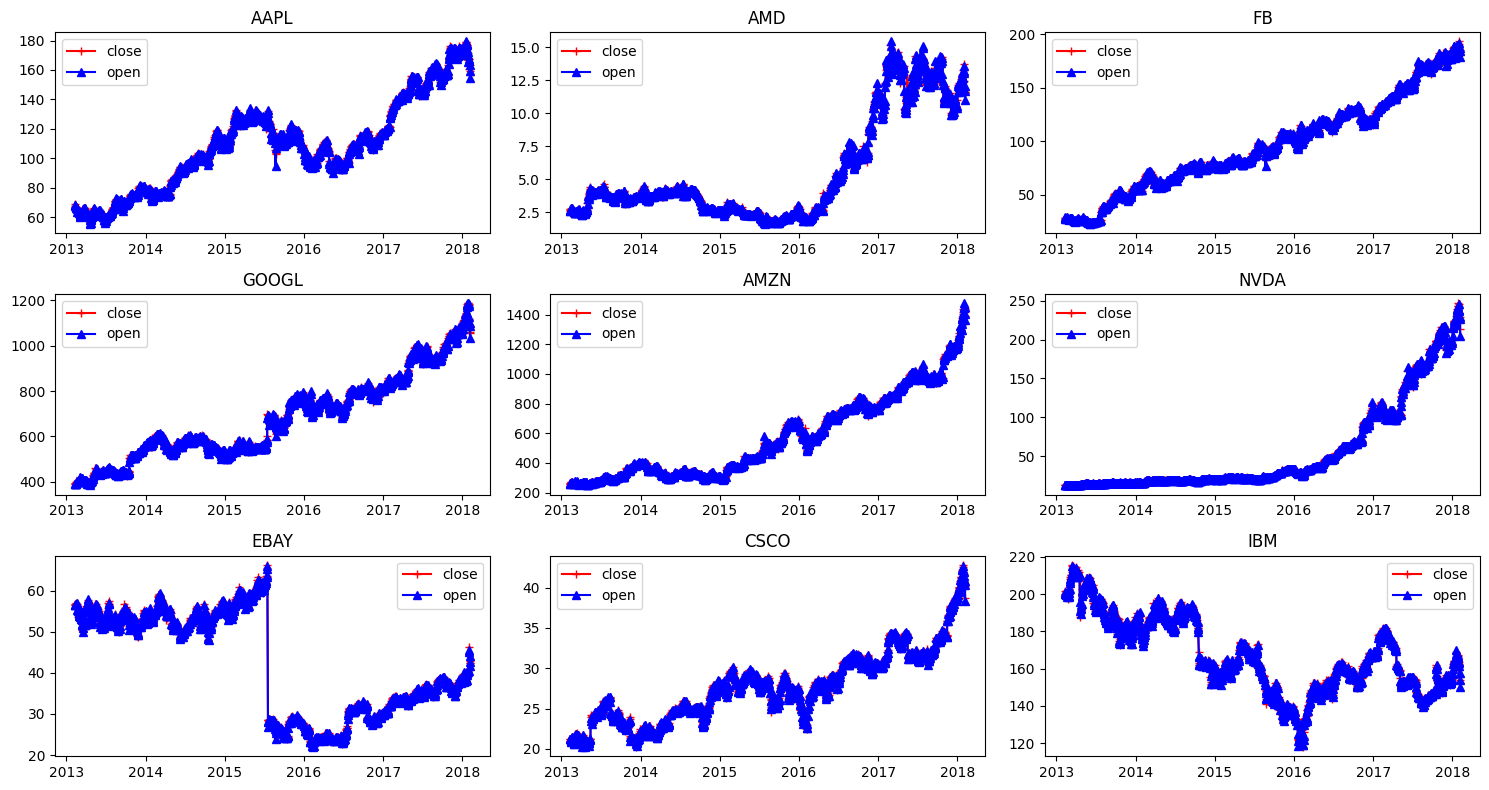

In [18]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = df[df['Name'] == company]
    plt.plot(c['date'], c['close'], c="r", label="close", marker="+")
    plt.plot(c['date'], c['open'], c="b", label="open", marker="^")
    plt.title(company)
    plt.legend()
    plt.tight_layout()
plt.show()

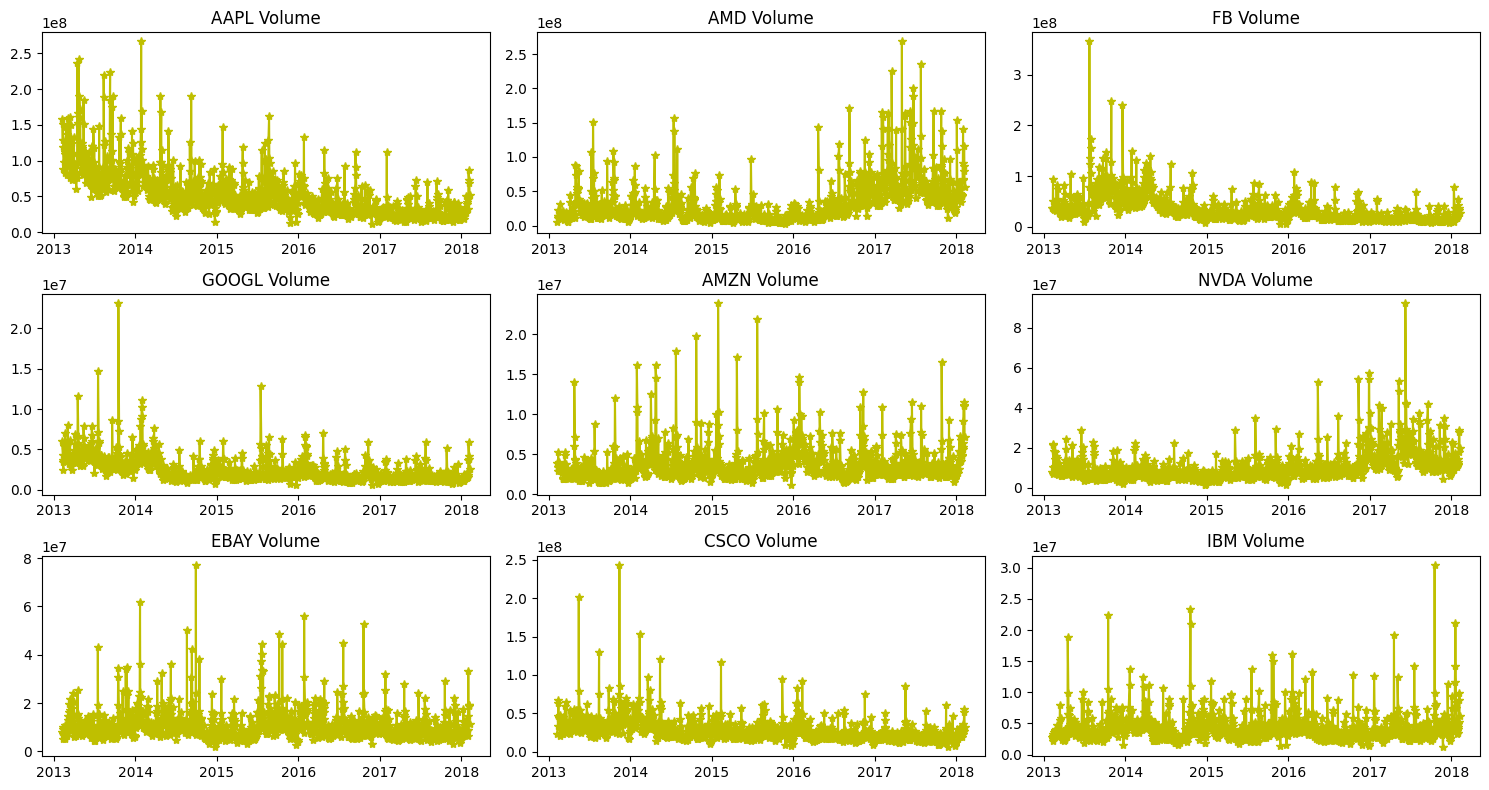

In [20]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = df[df['Name'] == company]
    plt.plot(c['date'], c['volume'], c='y', marker='*')
    plt.title(f"{company} Volume")
    plt.tight_layout()

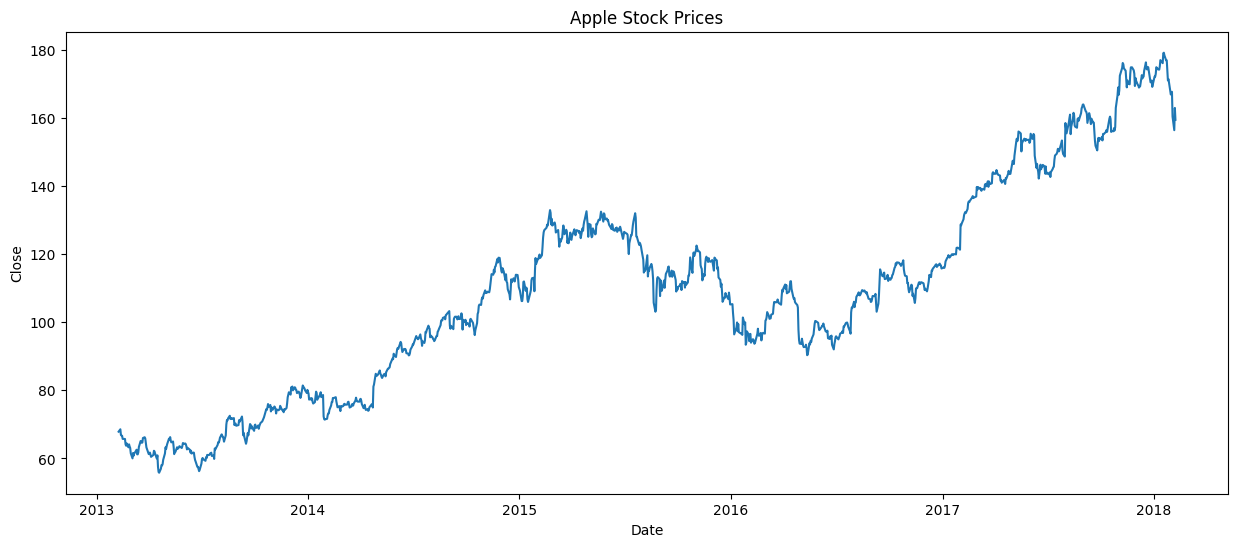

In [26]:
from datetime import datetime
apple = df[df['Name'] == 'AAPL']
prediction_range = apple.loc[(apple['date'] > datetime(2013,1,1))
 & (apple['date']<datetime(2018,1,1))]
plt.figure(figsize=(15, 6))
plt.plot(apple['date'],apple['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Apple Stock Prices")
plt.show()

In [28]:
close_data = apple.filter(['close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))
print(training)

1197


In [32]:
train_data = dataset[0:int(training), :]
# prepare feature and labels
X = []
y = []

for i in range(60, len(train_data)):
    X.append(train_data[i-60:i, 0])
    y.append(train_data[i, 0])

2. Train Test Split

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [35]:
X_train

array([[0.55599928, 0.55958836, 0.5568476 , ..., 0.50266325, 0.46656137,
        0.46684543],
       [0.81704207, 0.80578414, 0.81315583, ..., 0.78525924, 0.74390473,
        0.74516042],
       [0.36487189, 0.37264968, 0.38408526, ..., 0.46261168, 0.44453907,
        0.44006482],
       ...,
       [0.95563793, 0.97363201, 0.98563464, ..., 0.89540104, 0.87018886,
        0.90508137],
       [0.39128015, 0.39344165, 0.38824366, ..., 0.49998123, 0.48858367,
        0.47684579],
       [0.88287272, 0.97155281, 0.95784901, ..., 0.89155681, 0.86021   ,
        0.84677421]])

In [36]:
X_test

array([[0.46927   , 0.49040782, 0.5081755 , ..., 0.36918783, 0.33614806,
        0.32921341],
       [0.44970129, 0.46923781, 0.49295956, ..., 0.48514069, 0.45795891,
        0.45464161],
       [0.20119673, 0.19075967, 0.17948665, ..., 0.30490864, 0.29803915,
        0.30277179],
       ...,
       [0.46129053, 0.397222  , 0.36896383, ..., 0.38957122, 0.37520323,
        0.37040132],
       [0.69886986, 0.68859305, 0.6805598 , ..., 0.42452694, 0.4596794 ,
        0.48023574],
       [0.53510066, 0.54966492, 0.54352184, ..., 0.74672748, 0.71474238,
        0.70566749]])

In [37]:
y_train

[np.float64(108.98),
 np.float64(145.06),
 np.float64(109.48),
 np.float64(118.25),
 np.float64(61.4728),
 np.float64(68.7056),
 np.float64(64.6471),
 np.float64(75.7771),
 np.float64(99.16),
 np.float64(93.59),
 np.float64(95.97),
 np.float64(158.81),
 np.float64(112.98),
 np.float64(153.01),
 np.float64(111.86),
 np.float64(146.58),
 np.float64(116.31),
 np.float64(159.85),
 np.float64(75.8214),
 np.float64(109.73),
 np.float64(112.01),
 np.float64(71.2415),
 np.float64(127.1),
 np.float64(106.26),
 np.float64(119.04),
 np.float64(120.0),
 np.float64(114.48),
 np.float64(112.01),
 np.float64(109.4),
 np.float64(92.2242),
 np.float64(71.5742),
 np.float64(140.46),
 np.float64(73.5714),
 np.float64(93.48),
 np.float64(113.45),
 np.float64(96.68),
 np.float64(159.86),
 np.float64(74.8199),
 np.float64(132.17),
 np.float64(156.41),
 np.float64(126.01),
 np.float64(74.4479),
 np.float64(150.25),
 np.float64(152.76),
 np.float64(109.27),
 np.float64(101.58),
 np.float64(96.1),
 np.float64(

In [38]:
y_test

[np.float64(95.91),
 np.float64(109.11),
 np.float64(92.93),
 np.float64(159.98),
 np.float64(102.5),
 np.float64(69.9482),
 np.float64(127.8),
 np.float64(62.9985),
 np.float64(113.95),
 np.float64(75.8814),
 np.float64(94.2),
 np.float64(72.3099),
 np.float64(108.99),
 np.float64(100.35),
 np.float64(121.95),
 np.float64(117.26),
 np.float64(124.88),
 np.float64(107.93),
 np.float64(143.8),
 np.float64(108.72),
 np.float64(68.1071),
 np.float64(124.5),
 np.float64(138.99),
 np.float64(79.2842),
 np.float64(77.7799),
 np.float64(60.1042),
 np.float64(109.25),
 np.float64(93.52),
 np.float64(94.25),
 np.float64(70.0914),
 np.float64(71.5876),
 np.float64(93.24),
 np.float64(97.5),
 np.float64(127.3),
 np.float64(153.26),
 np.float64(62.6985),
 np.float64(125.69),
 np.float64(128.88),
 np.float64(126.6),
 np.float64(128.7),
 np.float64(96.45),
 np.float64(131.39),
 np.float64(142.27),
 np.float64(78.4385),
 np.float64(117.55),
 np.float64(91.0771),
 np.float64(66.8156),
 np.float64(120.

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### 4. Build the Model

In [40]:
import numpy as np
import tensorflow as tf

# ensure 3D input for LSTM
X_train = np.array(X_train).reshape((len(X_train), len(X_train[0]), 1))
X_test  = np.array(X_test).reshape((len(X_test), len(X_test[0]), 1))

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], 1)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)


##### 5. Compile and Fit the Model

In [44]:
# Ensure both inputs and targets are NumPy arrays with matching sample counts
X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
y_test = np.asarray(y_test, dtype=np.float32).reshape(-1, 1)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=1
)

X_train: (1023, 60, 1) y_train: (1023, 1)
X_test : (114, 60, 1) y_test : (114, 1)
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 11500.2305 - mae: 103.8428 - val_loss: 9923.5322 - val_mae: 96.5229
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 9084.0684 - mae: 91.1974 - val_loss: 7794.4019 - val_mae: 84.7789
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 7183.7021 - mae: 79.6220 - val_loss: 5801.0171 - val_mae: 72.0699
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 5256.2837 - mae: 65.9925 - val_loss: 3977.3567 - val_mae: 58.0553
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 3723.7739 - mae: 53.4323 - val_loss: 2490.6265 - val_mae: 43.6907
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 2475.1196 - mae: 40.8933 - val_loss: 1534.6353 - val_mae: 33.1420
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 1966.5760 - mae: 35.5940 - val_loss: 1035.1146 - val_mae: 27.2083
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 

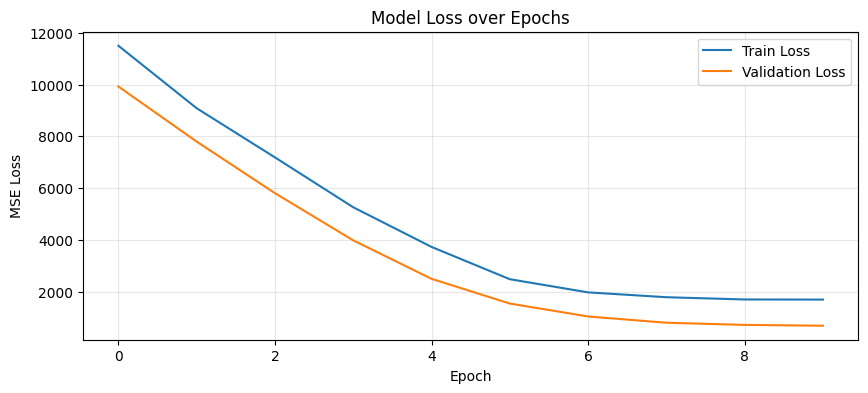

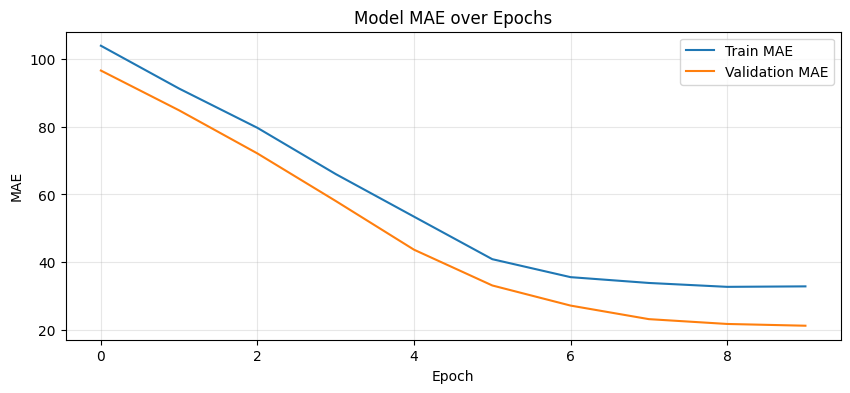

In [54]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### 6. Make Prediction

In [45]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


In [53]:
print(f"Actual: {y_test[0].item():.2f}, Predicted: {y_pred[0].item():.2f}")

Actual: 95.91, Predicted: 99.22


In [57]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y_test, y_pred)

677.571044921875

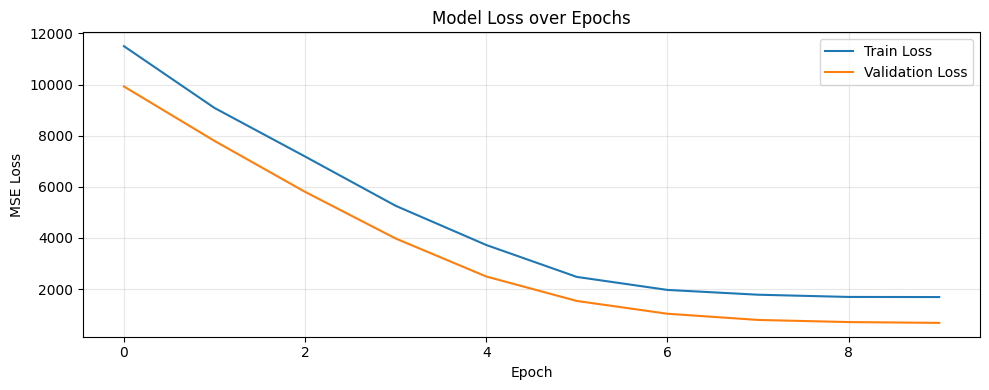

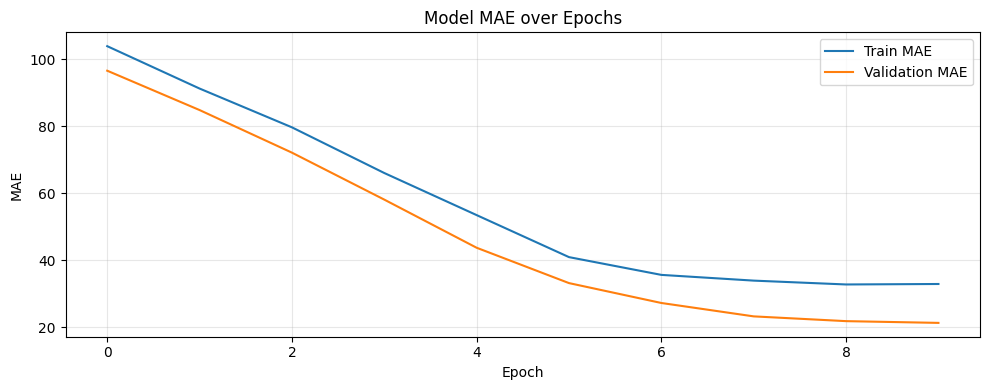

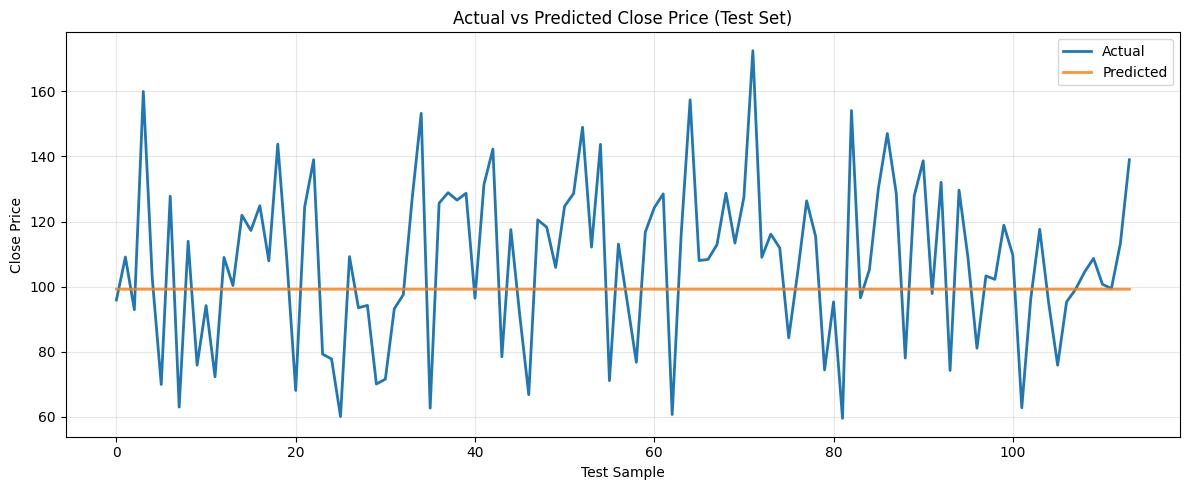

Saved images in: /Users/fatah/Desktop/100+Machine-Learning-Projects/23-Stock Price Prediction/docs/images


In [59]:
# Save plots for README
from pathlib import Path
import numpy as np

project_dir = Path('/Users/fatah/Desktop/100+Machine-Learning-Projects/23-Stock Price Prediction')
img_dir = project_dir / 'docs' / 'images'
img_dir.mkdir(parents=True, exist_ok=True)

# 1) Loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(img_dir / 'loss_curve.png', dpi=150)
plt.show()

# 2) MAE curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(img_dir / 'mae_curve.png', dpi=150)
plt.show()

# 3) Actual vs Predicted
y_true_flat = np.asarray(y_test).reshape(-1)
y_pred_flat = np.asarray(y_pred).reshape(-1)

plt.figure(figsize=(12, 5))
plt.plot(y_true_flat, label='Actual', linewidth=2)
plt.plot(y_pred_flat, label='Predicted', linewidth=2, alpha=0.85)
plt.title('Actual vs Predicted Close Price (Test Set)')
plt.xlabel('Test Sample')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(img_dir / 'actual_vs_predicted.png', dpi=150)
plt.show()

print('Saved images in:', img_dir)